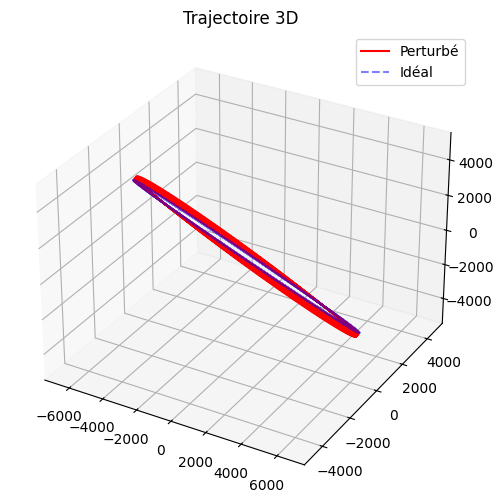

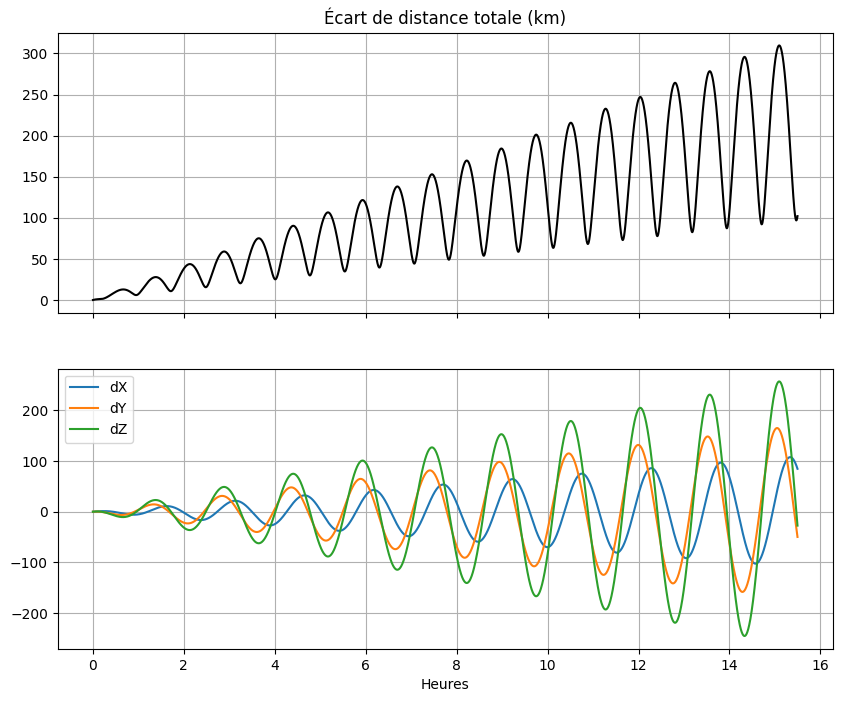

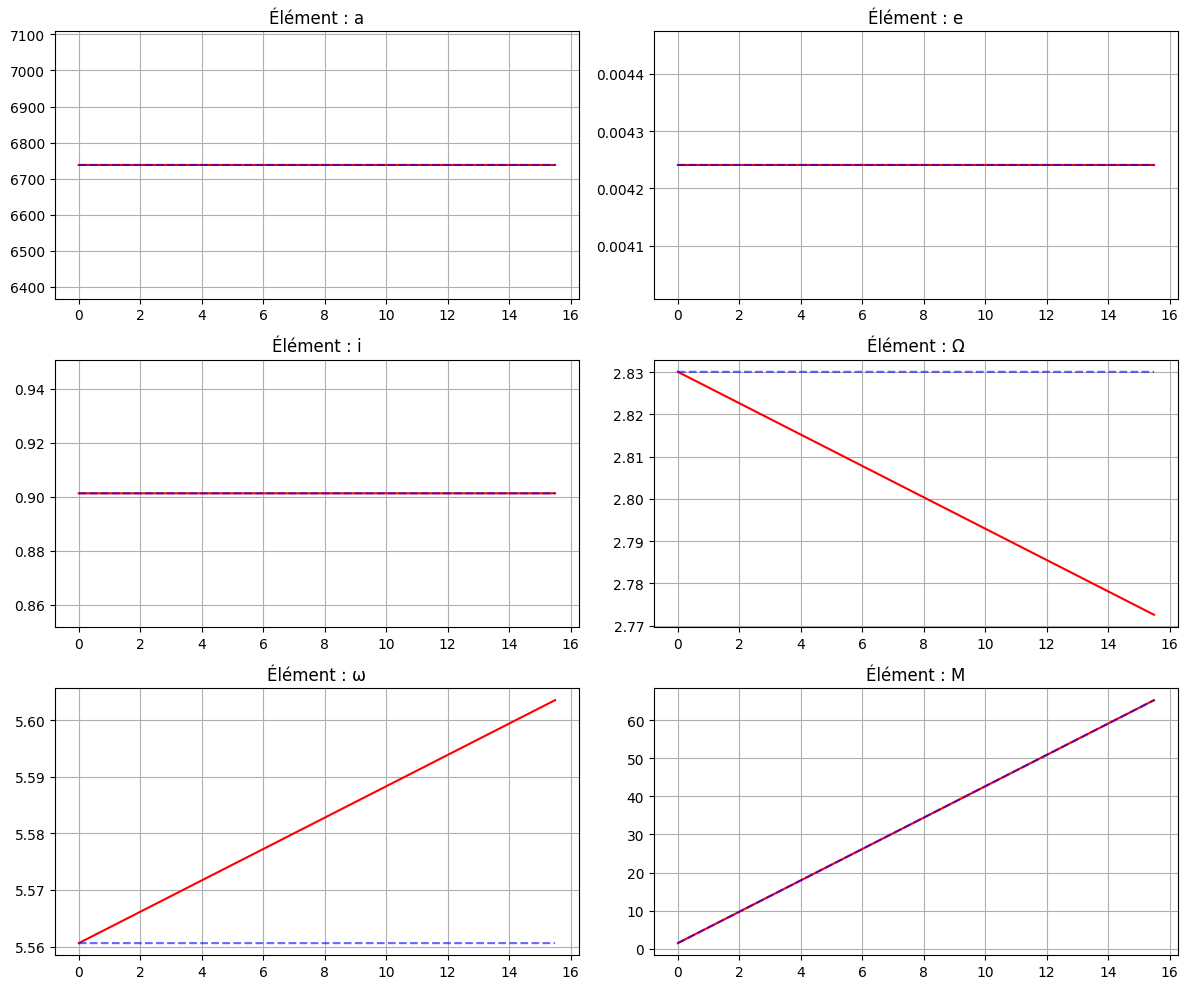

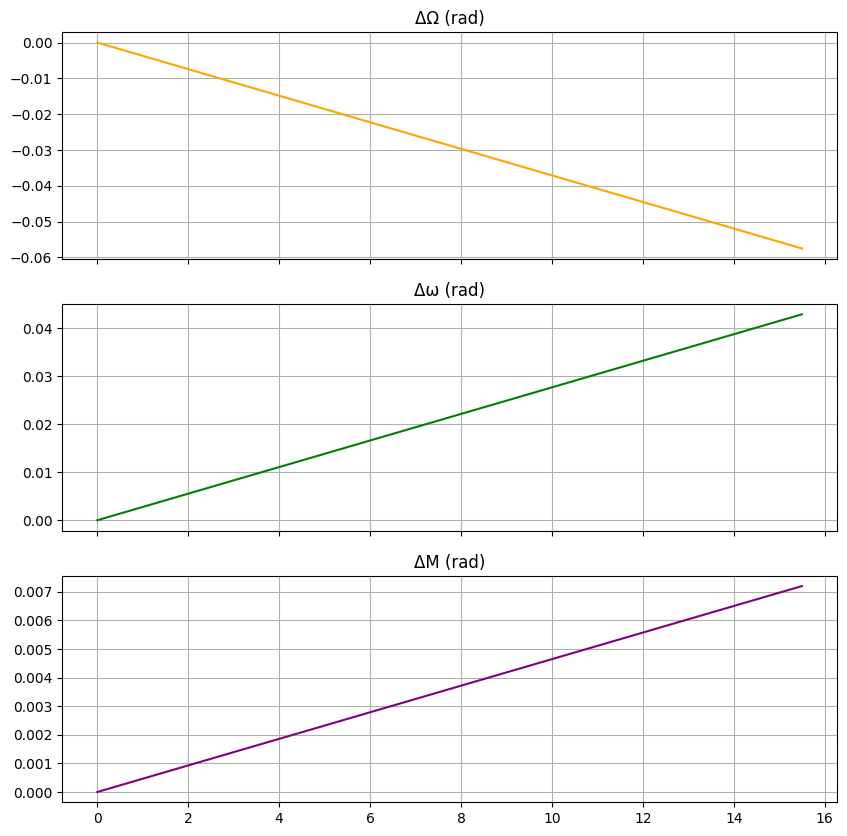

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from Internal_constants import *
from Internal_functions import *


# ---  CONFIGURATION ISS ---

a0, e0 = 6738.0, 0.004241
i0, w0, OMEGA0, M0 = np.radians([51.64, 318.6, 162.15, 86.77])
mu = 398600.44
n0 = np.sqrt(mu / a0**3)

t_array = np.arange(0, 15.5 * 3600, 10)
num_steps = len(t_array)

coords_pert = np.zeros((num_steps, 3))
coords_kepl = np.zeros((num_steps, 3))
elems_pert = np.zeros((num_steps, 6))
elems_kepl = np.zeros((num_steps, 6))

R_p = np.array([a0, e0, i0, OMEGA0, w0, M0])

# --- 3. CALCUL ---
for idx, t in enumerate(t_array):
    # Stockage Éléments
    elems_pert[idx] = R_p
    M_k = M0 + n0 * t
    elems_kepl[idx] = [a0, e0, i0, OMEGA0, w0, M_k]
    
    # Conversion Coordonnées
    coords_pert[idx] = keplerian_elements_to_cartesian([*R_p[:5], np.mod(R_p[5], 2*np.pi)])
    coords_kepl[idx] = keplerian_elements_to_cartesian([a0, e0, i0, OMEGA0, w0, np.mod(M_k, 2*np.pi)])
    
    # Intégration
    R_p = rk4_step_j2(R_p, t, 10)

# --- 4. VISUALISATION ---
t_hrs = t_array / 3600
diff = coords_pert - coords_kepl

# FIG 1 : ORBITE 3D
fig1 = plt.figure(figsize=(8, 6))
ax3d = fig1.add_subplot(111, projection='3d')
ax3d.plot(coords_pert[:, 0], coords_pert[:, 1], coords_pert[:, 2], 'r', label='Perturbé')
ax3d.plot(coords_kepl[:, 0], coords_kepl[:, 1], coords_kepl[:, 2], 'b--', alpha=0.5, label='Idéal')
ax3d.set_title("Trajectoire 3D")
ax3d.legend()

# FIG 2 : ÉCARTS DE POSITION (KM)
fig2, (ax_d, ax_xyz) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax_d.plot(t_hrs, np.linalg.norm(diff, axis=1), 'k')
ax_d.set_title("Écart de distance totale (km)")
ax_d.grid(True)
ax_xyz.plot(t_hrs, diff[:, 0], label='dX'); ax_xyz.plot(t_hrs, diff[:, 1], label='dY'); ax_xyz.plot(t_hrs, diff[:, 2], label='dZ')
ax_xyz.legend(); ax_xyz.set_xlabel("Heures"); ax_xyz.grid(True)

# FIG 3 : ELEMENTS KEPLERIENS BRUTS
labels = ['a', 'e', 'i', 'Ω', 'ω', 'M']
fig3, axs = plt.subplots(3, 2, figsize=(12, 10))
for i in range(6):
    ax = axs[i//2, i%2]
    ax.plot(t_hrs, elems_pert[:, i], 'r', label='Perturbé')
    ax.plot(t_hrs, elems_kepl[:, i], 'b--', alpha=0.6, label='Idéal')
    ax.set_title(f"Élément : {labels[i]}")
    ax.grid(True)
plt.tight_layout()

# FIG 4 : DIFFÉRENCES ANGULAIRES (Δ)
fig4, (ax_o, ax_w, ax_m) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
ax_o.plot(t_hrs, elems_pert[:, 3] - elems_kepl[:, 3], 'orange'); ax_o.set_title("ΔΩ (rad)"); ax_o.grid(True)
ax_w.plot(t_hrs, elems_pert[:, 4] - elems_kepl[:, 4], 'green'); ax_w.set_title("Δω (rad)"); ax_w.grid(True)
ax_m.plot(t_hrs, elems_pert[:, 5] - elems_kepl[:, 5], 'purple'); ax_m.set_title("ΔM (rad)"); ax_m.grid(True)

plt.show()

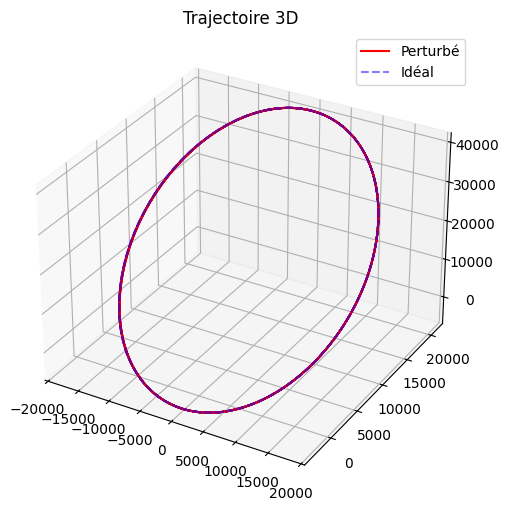

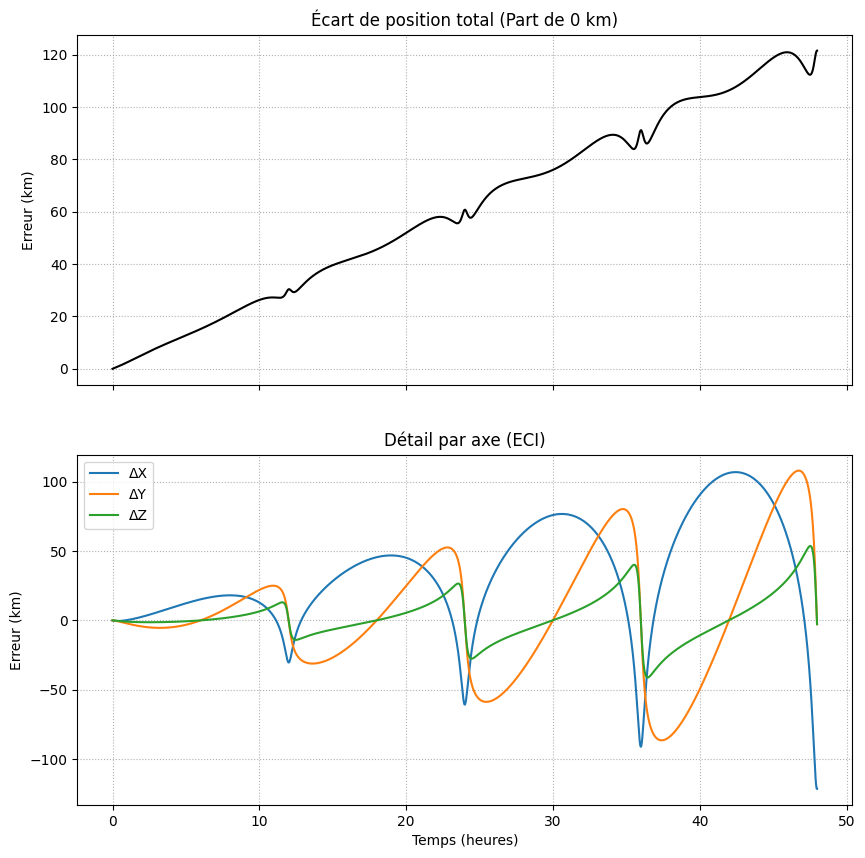

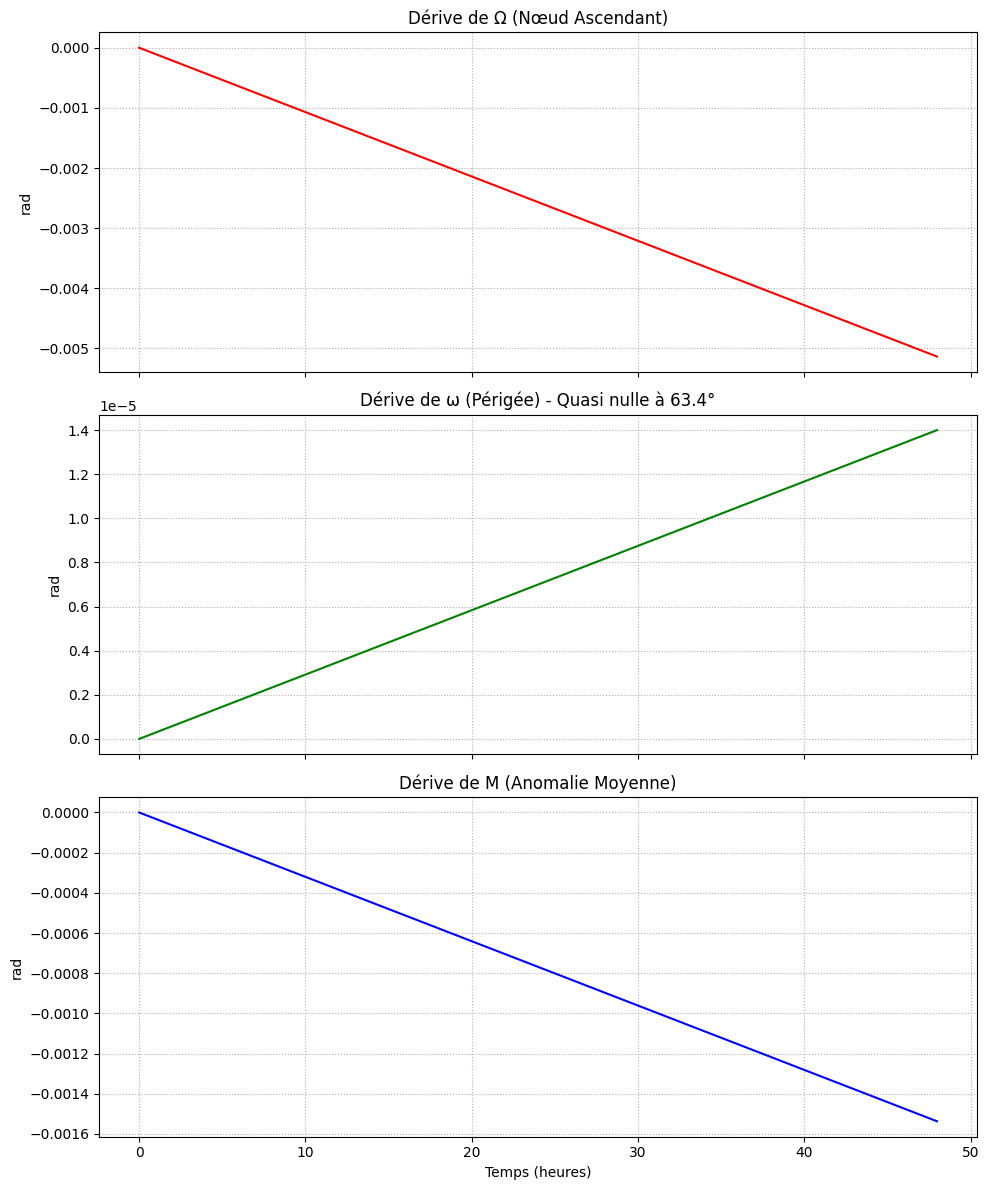

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from Internal_constants import *
from Internal_functions import *

# --- 4. INITIALISATION (ORBITE MOLNIYA) ---
# Paramètres de départ identiques pour les deux modèles
a0, e0 = 26600.0, 0.74
i0, OMEGA0, w0, M0 = np.radians([63.4, 0.0, 270.0, 0.0])
mu = 398600.44
n0 = np.sqrt(mu / a0**3)

t_init = 0.0
tf = 48 * 3600  # 2 jours
h = 60.0        # Pas de 1 min
t_array = np.arange(t_init, tf, h)
num_steps = len(t_array)

# Stockage
coords_pert = np.zeros((num_steps, 3))
coords_kepl = np.zeros((num_steps, 3))
delta_angles = np.zeros((num_steps, 3)) # [dOmega, dw, dM]

# État initial perturbé
R_p = np.array([a0, e0, i0, OMEGA0, w0, M0])

# --- 5. BOUCLE DE CALCUL ---
for idx, t in enumerate(t_array):
    # --- Modèle Perturbé ---
    # Conversion (avec modulo pour la trigo)
    R_p_conv = R_p.copy()
    R_p_conv[5] = np.mod(R_p_conv[5], 2*np.pi)
    coords_pert[idx] = keplerian_elements_to_cartesian(R_p_conv)
    
    # --- Modèle Képlérien ---
    M_k = M0 + n0 * t # t_init étant 0, delta_t = t
    R_k = np.array([a0, e0, i0, OMEGA0, w0, M_k])
    coords_kepl[idx] = keplerian_elements_to_cartesian(np.array([*R_k[:5], np.mod(M_k, 2*np.pi)]))
    
    # Écarts angulaires
    delta_angles[idx] = R_p[3:] - R_k[3:]
    
    # Intégration pour le pas suivant
    R_p = rk4_step_j2(R_p, t, h)

# --- 6. CALCUL DES ÉCARTS DE POSITION ---
diff_xyz = coords_pert - coords_kepl
dist_err = np.linalg.norm(diff_xyz, axis=1)
t_hrs = t_array / 3600

# --- 7. VISUALISATION ---
# FIG 1 : ORBITE 3D
fig0 = plt.figure(figsize=(8, 6))
ax3d = fig0.add_subplot(111, projection='3d')
ax3d.plot(coords_pert[:, 0], coords_pert[:, 1], coords_pert[:, 2], 'r', label='Perturbé')
ax3d.plot(coords_kepl[:, 0], coords_kepl[:, 1], coords_kepl[:, 2], 'b--', alpha=0.5, label='Idéal')
ax3d.set_title("Trajectoire 3D")
ax3d.legend()

# Plot 1 : Écarts Cartésiens (XYZ et Distance)
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
ax1.plot(t_hrs, dist_err, 'k', label='Distance 3D')
ax1.set_title("Écart de position total (Part de 0 km)")
ax1.set_ylabel("Erreur (km)")
ax1.grid(True, ls=':')

ax2.plot(t_hrs, diff_xyz[:, 0], label='ΔX')
ax2.plot(t_hrs, diff_xyz[:, 1], label='ΔY')
ax2.plot(t_hrs, diff_xyz[:, 2], label='ΔZ')
ax2.set_title("Détail par axe (ECI)")
ax2.set_xlabel("Temps (heures)")
ax2.set_ylabel("Erreur (km)")
ax2.legend()
ax2.grid(True, ls=':')

# Plot 2 : Écarts des éléments (Résidus)
fig2, (ax3, ax4, ax5) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
ax3.plot(t_hrs, delta_angles[:, 0], 'r')
ax3.set_title("Dérive de Ω (Nœud Ascendant)")
ax3.set_ylabel("rad")
ax3.grid(True, ls=':')

ax4.plot(t_hrs, delta_angles[:, 1], 'g')
ax4.set_title("Dérive de ω (Périgée) - Quasi nulle à 63.4°")
ax4.set_ylabel("rad")
ax4.grid(True, ls=':')

ax5.plot(t_hrs, delta_angles[:, 2], 'b')
ax5.set_title("Dérive de M (Anomalie Moyenne)")
ax5.set_ylabel("rad")
ax5.set_xlabel("Temps (heures)")
ax5.grid(True, ls=':')

plt.tight_layout()
plt.show()